# Fuzzy c-means clustering

Fuzzy logic principles can be applied to cluster grocery inventory and sales data, assigning each product a *degree of membership* in multiple demand groups rather than a single hard label.  
This is useful for identifying patterns such as **fast-moving**, **slow-moving**, or **balanced** items based on their sales rate and stock level.

Fuzzy c-means clustering is performed using `skfuzzy.cmeans`, which produces soft cluster memberships for each item.  
The resulting model can then be used to **classify new products or time periods** according to these learned cluster profiles through `skfuzzy.cmeans_predict`.

# Data loading and setup

In this example, we will begin by importing the necessary libraries and then loading the **grocery inventory and sales dataset**.  
This data contains features such as **current stock levels**, **maximum capacity**, and **recent sales rate**, which we will later process to compute `stock_level%` and `sales_rate%` values for clustering.

Text(0.5, 1.0, 'Grocery test data: 200 points x3 clusters (Sales% vs Stock%).')

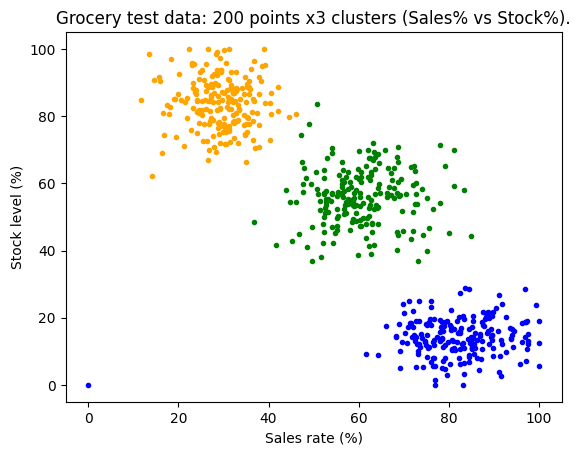

In [15]:
from __future__ import division, print_function
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

colors = ['b', 'orange', 'g', 'r', 'c', 'm', 'y', 'k', 'Brown', 'ForestGreen']

# Define three cluster centers  (x = sales rate %, y = stock level %)
centers = [[82, 15],   # fast-moving, low stock
           [30, 85],   # slow/avg sales, high stock
           [60, 55]]   # balanced

# Define three cluster sigmas in x and y, respectively (spread in percentage units)
sigmas = [[8, 6],
          [6, 8],
          [9, 9]]

# Generate test data
np.random.seed(0)  # Set seed for reproducibility
xpts = np.zeros(1)
ypts = np.zeros(1)
labels = np.zeros(1)
for i, ((xmu, ymu), (xsigma, ysigma)) in enumerate(zip(centers, sigmas)):
    xpts = np.hstack((xpts, np.random.standard_normal(200) * xsigma + xmu))
    ypts = np.hstack((ypts, np.random.standard_normal(200) * ysigma + ymu))
    labels = np.hstack((labels, np.ones(200) * i))

# Clip to valid 0–100% ranges (keeps the same structure)
xpts = np.clip(xpts, 0, 100)
ypts = np.clip(ypts, 0, 100)

# Visualize the test data
fig0, ax0 = plt.subplots()
for label in range(3):
    ax0.plot(xpts[labels == label], ypts[labels == label], '.',
             color=colors[label])
ax0.set_xlabel('Sales rate (%)')
ax0.set_ylabel('Stock level (%)')
ax0.set_title('Grocery test data: 200 points x3 clusters (Sales% vs Stock%).')

# Clustering

Above is our grocery sales and stock data. We can observe three general groups of items — fast-moving with low stock, slow-moving with high stock, and balanced items.  
However, what if we didn’t know how many such demand clusters to expect?  
Perhaps the data is not so clearly separated in real-world grocery situations.

Let’s try clustering our data several times, testing between 2 and 9 clusters, to see how well the fuzzy c-means algorithm identifies meaningful product groups.

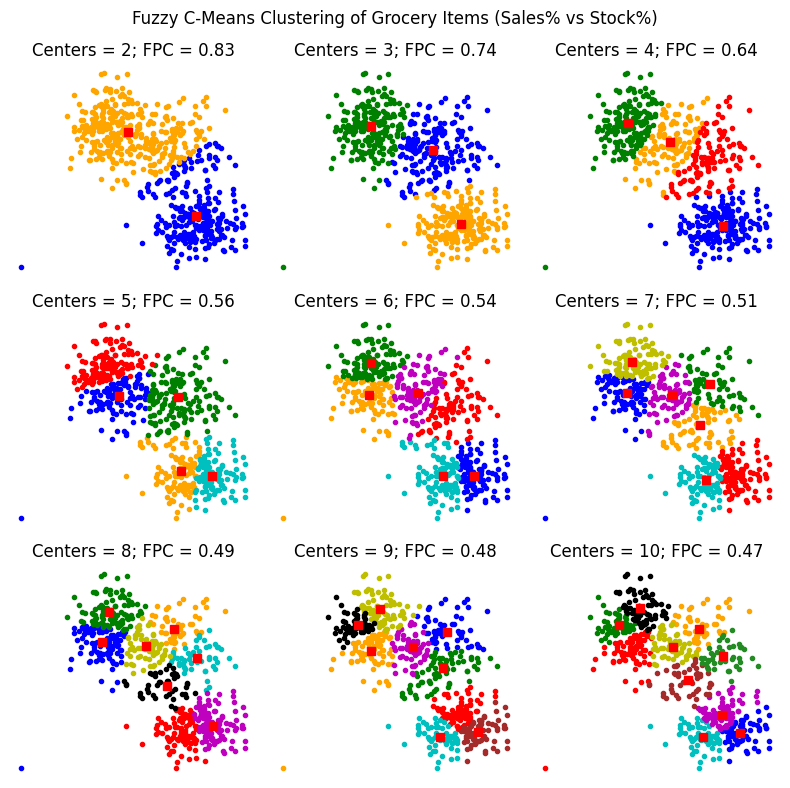

In [13]:
# Set up the loop and plot
fig1, axes1 = plt.subplots(3, 3, figsize=(8, 8))
alldata = np.vstack((xpts, ypts))
fpcs = []

# Try clustering grocery data with 2–9 clusters
for ncenters, ax in enumerate(axes1.reshape(-1), 2):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        alldata, ncenters, 2, error=0.005, maxiter=1000, init=None)

    # Store FPC (Fuzzy Partition Coefficient) for later comparison
    fpcs.append(fpc)

    # Plot assigned clusters for each grocery item
    cluster_membership = np.argmax(u, axis=0)
    for j in range(ncenters):
        ax.plot(xpts[cluster_membership == j],
                ypts[cluster_membership == j], '.', color=colors[j])

    # Mark the center of each fuzzy cluster
    for pt in cntr:
        ax.plot(pt[0], pt[1], 'rs')

    ax.set_title(f'Centers = {ncenters}; FPC = {fpc:.2f}')
    ax.set_xlabel('Sales rate (%)')
    ax.set_ylabel('Stock level (%)')
    ax.axis('off')

fig1.suptitle('Fuzzy C-Means Clustering of Grocery Items (Sales% vs Stock%)')
fig1.tight_layout()

# The fuzzy partition coefficient (FPC)

The FPC ranges from 0 to 1, with values closer to 1 indicating a cleaner and more distinct clustering.  
It measures how well the fuzzy c-means model describes the grocery data for a given number of clusters.

Next, we will cluster our grocery items — which we expect to form around three main groups — several times using between 2 and 9 clusters.  
We will then display the clustering results and plot the fuzzy partition coefficient.  
The number of clusters that produces the **highest FPC value** represents the model that best describes our grocery item segmentation.

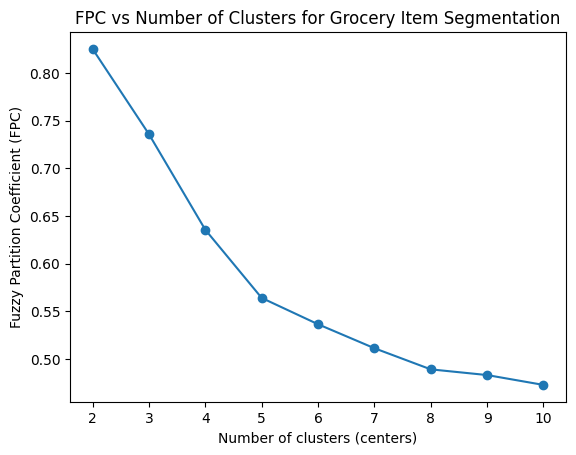

In [17]:
fig2, ax2 = plt.subplots()
ax2.plot(np.arange(2, 2 + len(fpcs)), fpcs, marker='o') 
ax2.set_xlabel("Number of clusters (centers)")
ax2.set_ylabel("Fuzzy Partition Coefficient (FPC)")
ax2.set_title("FPC vs Number of Clusters for Grocery Item Segmentation")
plt.show()

 

From the graph above, we can see that the Fuzzy Partition Coefficient (FPC) is highest when the number of clusters is **2**, and it gradually decreases as more clusters are added.  

This indicates that, for our grocery data, **two clusters** describe the items most clearly — likely separating products into two main groups, such as **fast-moving** and **slow-moving** items.  

As the number of clusters increases, the FPC drops, showing that additional clusters start to overlap and reduce clarity.  
We also started the test from two clusters instead of one, since using only a single cluster is a trivial case and always results in an FPC value of 1.

# Classifying New Grocery Data

Now that we have clustered our grocery data, the next step is to assign **new or unseen items** to the existing clusters.  
This process is known as **prediction**, and it requires both a trained fuzzy c-means model and the new item data to classify.

## Building the model
We’ve observed that our best model uses **two clusters** (fast-moving and slow-moving items).  
We will rebuild this 2-cluster fuzzy c-means model for use in prediction, generate new synthetic grocery data points (Sales% and Stock%), and predict which cluster each new item most likely belongs to.

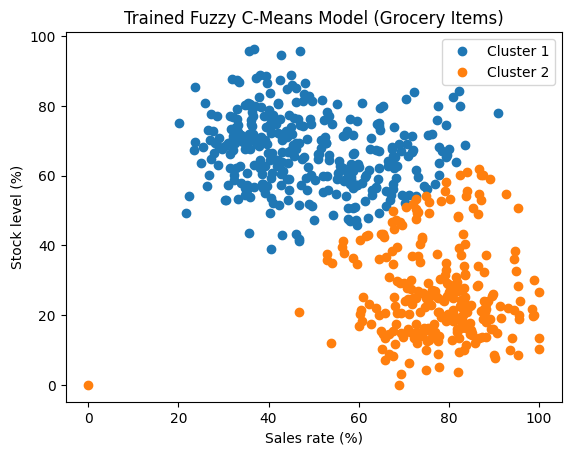

In [18]:
# Rebuild fuzzy model with 2 cluster centers - note that center ordering
# is random in this clustering algorithm, so the centers may change places
cntr, u_orig, _, _, _, _, _ = fuzz.cluster.cmeans(
    alldata, 2, 2, error=0.005, maxiter=1000)

# Show 2-cluster model for grocery items
fig2, ax2 = plt.subplots()
ax2.set_title('Trained Fuzzy C-Means Model (Grocery Items)')
for j in range(2):
    ax2.plot(alldata[0, u_orig.argmax(axis=0) == j],
             alldata[1, u_orig.argmax(axis=0) == j], 'o',
             label=f'Cluster {j + 1}')
ax2.set_xlabel('Sales rate (%)')
ax2.set_ylabel('Stock level (%)')
ax2.legend()
plt.show()

# Prediction

Finally, we generate new, uniformly sampled grocery item data — representing possible combinations of **sales rate** and **stock level** — and classify these items using our trained fuzzy c-means model through `cmeans_predict`.  
This allows us to assign new or future grocery items to one of the existing clusters (e.g., **fast-moving** or **slow-moving**) based on their characteristics.

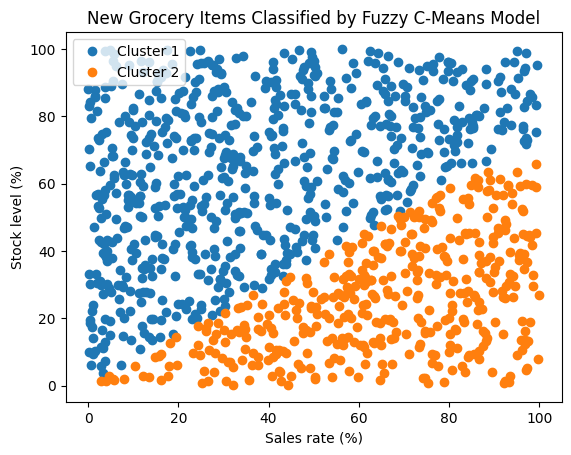

In [19]:
# Generate uniformly sampled grocery data across realistic Sales% and Stock% ranges (0–100)
newdata = np.random.uniform(0, 100, (1100, 2))

# Predict new cluster membership using `cmeans_predict` and the trained 2-cluster model
u, u0, d, jm, p, fpc = fuzz.cluster.cmeans_predict(
    newdata.T, cntr, 2, error=0.005, maxiter=1000)

# For visualization, we use the cluster with the highest membership for each point
cluster_membership = np.argmax(u, axis=0)  # Hardening for visualization

# Plot classified grocery items based on learned cluster centers
fig3, ax3 = plt.subplots()
ax3.set_title('New Grocery Items Classified by Fuzzy C-Means Model')
for j in range(2):
    ax3.plot(newdata[cluster_membership == j, 0],
             newdata[cluster_membership == j, 1], 'o',
             label=f'Cluster {j + 1}')
ax3.set_xlabel('Sales rate (%)')
ax3.set_ylabel('Stock level (%)')
ax3.legend()

plt.show()

Source adapted from: scikit-fuzzy official example — Fuzzy c-means clustering,
available at: https://scikit-fuzzy.readthedocs.io/en/latest/auto_examples/plot_cmeans.html
